# Pracownia 3

## Importym

In [28]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import statsmodels.api as sm

## Zadanie 1

In [2]:
REPEATS = 10000
ALPHA = 0.05
N_VALUES = [20, 50, 100]

np.random.seed(42)

In [3]:
def calc_ci_mean_known_var(data, true_var, alpha=0.05):
    """
    Przedział ufności dla średniej (wariancja znana).
    Korzysta z rozkładu normalnego (Z).
    """
    n = len(data)
    mean = np.mean(data)
    sigma = np.sqrt(true_var)
    z_score = stats.norm.ppf(1 - alpha/2)
    margin = z_score * (sigma / np.sqrt(n))
    return mean - margin, mean + margin

def calc_ci_mean_unknown_var(data, alpha=0.05):
    """
    Przedział ufności dla średniej (wariancja nieznana).
    Korzysta z rozkładu t-Studenta.
    """
    n = len(data)
    mean = np.mean(data)
    s = np.std(data, ddof=1)
    t_score = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_score * (s / np.sqrt(n))
    return mean - margin, mean + margin

def calc_ci_variance(data, alpha=0.05):
    """
    Przedział ufności dla wariancji.
    Korzysta z rozkładu Chi-kwadrat (zakłada normalność danych).
    """
    n = len(data)
    s2 = np.var(data, ddof=1)
    chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
    chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)

    ci_low = (n - 1) * s2 / chi2_upper
    ci_high = (n - 1) * s2 / chi2_lower
    return ci_low, ci_high

In [4]:
scenarios = {
    '1a_Norm(0,1)': {
        'gen': lambda n: np.random.normal(loc=0, scale=1, size=n),
        'true_mean': 0,
        'true_var': 1**2
    },
    '1b_Norm(0,2)': {
        'gen': lambda n: np.random.normal(loc=0, scale=2, size=n),
        'true_mean': 0,
        'true_var': 2**2
    },
    '2a_Logist(0,1)': {
        'gen': lambda n: np.random.logistic(loc=0, scale=1, size=n),
        'true_mean': 0,
        'true_var': (1**2 * np.pi**2) / 3
    },
    '2b_Logist(0,2)': {
        'gen': lambda n: np.random.logistic(loc=0, scale=2, size=n),
        'true_mean': 0,
        'true_var': (2**2 * np.pi**2) / 3
    },
    '3a_t(3)': {
        'gen': lambda n: np.random.standard_t(df=3, size=n),
        'true_mean': 0,
        'true_var': 3 / (3-2)
    },
    '3b_t(10)': {
        'gen': lambda n: np.random.standard_t(df=10, size=n),
        'true_mean': 0,
        'true_var': 10 / (10-2)
    },
    '3c_t(20)': {
        'gen': lambda n: np.random.standard_t(df=20, size=n),
        'true_mean': 0,
        'true_var': 20 / (20-2)
    },
    '4a_Laplace(0,1)': {
        'gen': lambda n: np.random.laplace(loc=0, scale=1, size=n),
        'true_mean': 0,
        'true_var': 2 * 1**2
    },
    '4b_Laplace(0,1/3)': {
        'gen': lambda n: np.random.laplace(loc=0, scale=1/3, size=n),
        'true_mean': 0,
        'true_var': 2 * (1/3)**2
    }
}

In [5]:
results_list = []

for n in N_VALUES:

    for name, params in tqdm(scenarios.items()):
        cov_mean_known = 0
        cov_mean_unknown = 0
        cov_variance = 0

        true_mean = params['true_mean']
        true_var = params['true_var']
        generator = params['gen']

        for _ in range(REPEATS):
            data = generator(n)

            ci_m_k = calc_ci_mean_known_var(data, true_var, ALPHA)
            ci_m_u = calc_ci_mean_unknown_var(data, ALPHA)
            ci_v = calc_ci_variance(data, ALPHA)

            if ci_m_k[0] <= true_mean <= ci_m_k[1]:
                cov_mean_known += 1
            if ci_m_u[0] <= true_mean <= ci_m_u[1]:
                cov_mean_unknown += 1
            if ci_v[0] <= true_var <= ci_v[1]:
                cov_variance += 1

        results_list.append({
            'N': n,
            'Case': name,
            'Cov_Mean_VarKnown': cov_mean_known / REPEATS,
            'Cov_Mean_VarUnknown': cov_mean_unknown / REPEATS,
            'Cov_Variance': cov_variance / REPEATS
        })

df_results = pd.DataFrame(results_list)

display(df_results)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

,N,Case,Cov_Mean_VarKnown,Cov_Mean_VarUnknown,Cov_Variance
0,20,"1a_Norm(0,1)",0.9488,0.9468,0.9492
1,20,"1b_Norm(0,2)",0.9489,0.9490,0.9486
2,20,"2a_Logist(0,1)",0.9472,0.9508,0.8984
3,20,"2b_Logist(0,2)",0.9494,0.9502,0.8941
4,20,3a_t(3),0.9547,0.9601,0.6661
5,20,3b_t(10),0.9523,0.9531,0.9076
6,20,3c_t(20),0.9509,0.9484,0.9316
7,20,"4a_Laplace(0,1)",0.9495,0.9519,0.8204
8,20,"4b_Laplace(0,1/3)",0.9449,0.9512,0.8201
9,50,"1a_Norm(0,1)",0.9500,0.9504,0.9488


In [6]:
df_results.to_markdown(index=False)

'|   N | Case              |   Cov_Mean_VarKnown |   Cov_Mean_VarUnknown |   Cov_Variance |\n|----:|:------------------|--------------------:|----------------------:|---------------:|\n|  20 | 1a_Norm(0,1)      |              0.9488 |                0.9468 |         0.9492 |\n|  20 | 1b_Norm(0,2)      |              0.9489 |                0.949  |         0.9486 |\n|  20 | 2a_Logist(0,1)    |              0.9472 |                0.9508 |         0.8984 |\n|  20 | 2b_Logist(0,2)    |              0.9494 |                0.9502 |         0.8941 |\n|  20 | 3a_t(3)           |              0.9547 |                0.9601 |         0.6661 |\n|  20 | 3b_t(10)          |              0.9523 |                0.9531 |         0.9076 |\n|  20 | 3c_t(20)          |              0.9509 |                0.9484 |         0.9316 |\n|  20 | 4a_Laplace(0,1)   |              0.9495 |                0.9519 |         0.8204 |\n|  20 | 4b_Laplace(0,1/3) |              0.9449 |                0.9512 |      

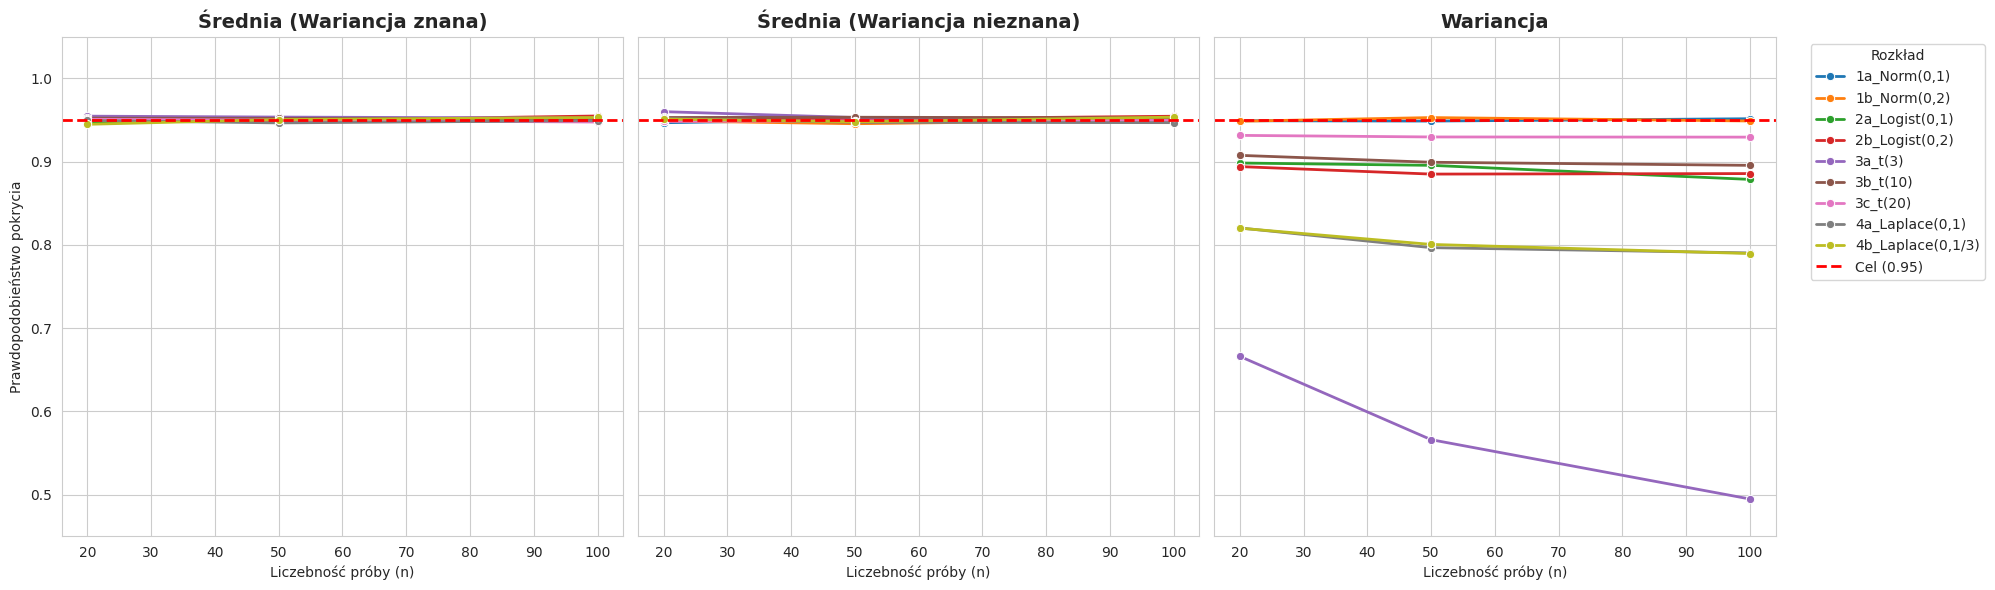

In [8]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

metrics = [
    ('Cov_Mean_VarKnown', 'Średnia (Wariancja znana)'),
    ('Cov_Mean_VarUnknown', 'Średnia (Wariancja nieznana)'),
    ('Cov_Variance', 'Wariancja')
]

for i, (col_name, title) in enumerate(metrics):
    ax = axes[i]

    sns.lineplot(
        data=df_results,
        x='N',
        y=col_name,
        hue='Case',
        marker='o',
        linewidth=2,
        ax=ax
    )

    ax.axhline(0.95, color='red', linestyle='--', linewidth=2, label='Cel (0.95)')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Liczebność próby (n)")
    if i == 0:
        ax.set_ylabel("Prawdopodobieństwo pokrycia")
    ax.set_ylim(0.45, 1.05)

    if i < 2:
        ax.get_legend().remove()
    else:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rozkład')

plt.tight_layout()
plt.show()

Jak interpretować te wykresy (do raportu):

Wykres 1 i 2 (Średnia):

Zauważysz, że linie oscylują wokół czerwonej przerywanej linii 0.95.

Oznacza to, że przedziały ufności dla średniej są odporne. Nawet jeśli dane pochodzą z dziwnego rozkładu (np. Laplace), metoda t-Studenta (VarUnknown) działa poprawnie, zwłaszcza przy n=50 i n=100.

Wykres 3 (Wariancja) - Najważniejszy wniosek:

Tutaj zobaczysz "katastrofę". Tylko linie odpowiadające przypadkom Normalnym (1a, 1b) będą blisko poziomu 0.95.

Wszystkie inne linie (Laplace, t-Student) spadną drastycznie w dół (często w okolice 0.4 - 0.7).

Wniosek: Standardowy przedział ufności dla wariancji (oparty na χ2) jest bezużyteczny, jeśli dane nie są idealnie normalne. Rozkłady o "grubszych ogonach" (jak na wykresie z Komórki 7) powodują, że wariancja próbkowa jest bardzo zmienna, a wzór tego nie uwzględnia.

## Zadanie 2

In [11]:
REPEATS = 10000
ALPHA = 0.05
Z_SCORE = stats.norm.ppf(1 - ALPHA/2)
N_VALUES = np.arange(5, 101, 1)

In [12]:
def simulate_beta(true_theta, n_values):
    coverage_probs = []

    for n in tqdm(n_values, desc=f"Beta(theta={true_theta})"):
        data = np.random.beta(a=true_theta, b=1, size=(REPEATS, n))

        log_data = np.log(data)
        sum_log = np.sum(log_data, axis=1)
        theta_hat = -n / sum_log

        se = theta_hat / np.sqrt(n)

        ci_lower = theta_hat - Z_SCORE * se
        ci_upper = theta_hat + Z_SCORE * se

        covered = (ci_lower <= true_theta) & (true_theta <= ci_upper)

        coverage_probs.append(np.mean(covered))

    return coverage_probs

def simulate_lognorm(true_theta, true_sigma, n_values):
    coverage_probs = []

    for n in tqdm(n_values, desc=f"Lognorm(th={true_theta}, sig={true_sigma})"):
        data = np.random.lognormal(mean=true_theta, sigma=true_sigma, size=(REPEATS, n))

        log_data = np.log(data)
        theta_hat = np.mean(log_data, axis=1)

        se = true_sigma / np.sqrt(n)

        ci_lower = theta_hat - Z_SCORE * se
        ci_upper = theta_hat + Z_SCORE * se

        covered = (ci_lower <= true_theta) & (true_theta <= ci_upper)
        coverage_probs.append(np.mean(covered))

    return coverage_probs

In [13]:
results_beta_05 = simulate_beta(true_theta=0.5, n_values=N_VALUES)
results_beta_5 = simulate_beta(true_theta=5, n_values=N_VALUES)

results_lognorm_1 = simulate_lognorm(true_theta=0, true_sigma=1, n_values=N_VALUES)
results_lognorm_2 = simulate_lognorm(true_theta=0, true_sigma=2, n_values=N_VALUES)

Beta(theta=0.5):   0%|          | 0/96 [00:00<?, ?it/s]

Beta(theta=5):   0%|          | 0/96 [00:00<?, ?it/s]

Lognorm(th=0, sig=1):   0%|          | 0/96 [00:00<?, ?it/s]

Lognorm(th=0, sig=2):   0%|          | 0/96 [00:00<?, ?it/s]

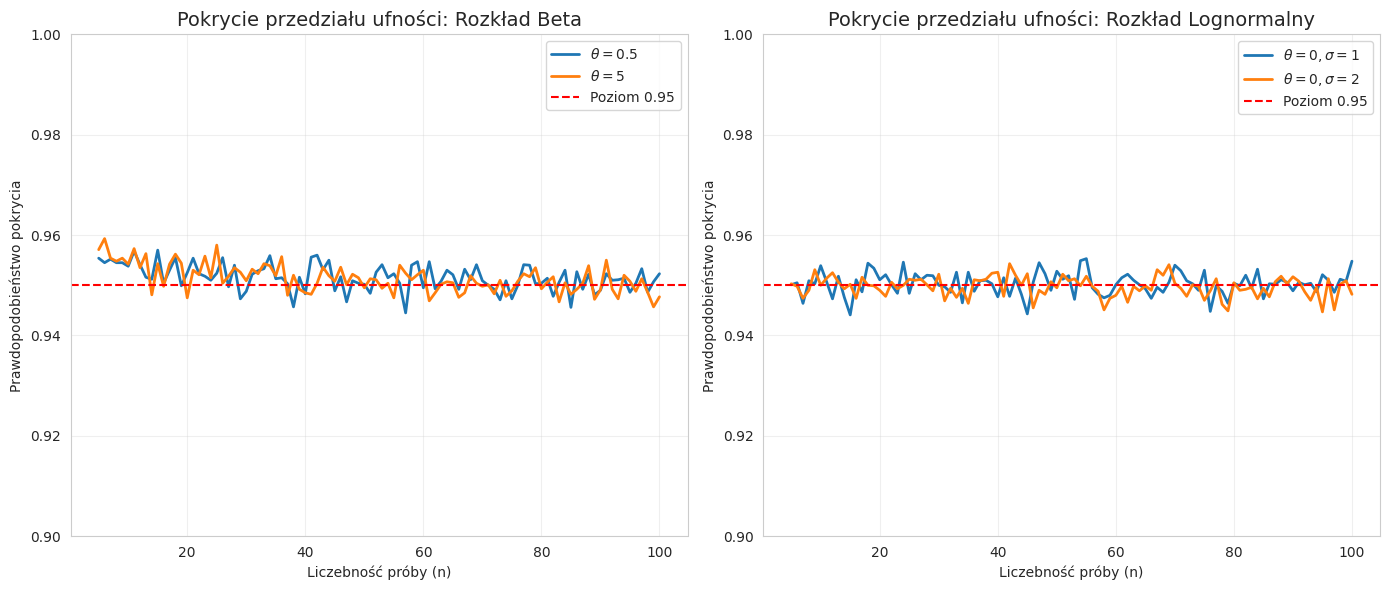

In [16]:
plt.figure(figsize=(14, 6))

# --- Wykres 1: Rozkład Beta ---
plt.subplot(1, 2, 1)
plt.plot(N_VALUES, results_beta_05, label=r'$\theta=0.5$', linewidth=2)
plt.plot(N_VALUES, results_beta_5, label=r'$\theta=5$', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Poziom 0.95')

plt.title('Pokrycie przedziału ufności: Rozkład Beta', fontsize=14)
plt.xlabel('Liczebność próby (n)')
plt.ylabel('Prawdopodobieństwo pokrycia')
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(N_VALUES, results_lognorm_1, label=r'$\theta=0, \sigma=1$', linewidth=2)
plt.plot(N_VALUES, results_lognorm_2, label=r'$\theta=0, \sigma=2$', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='Poziom 0.95')

plt.title('Pokrycie przedziału ufności: Rozkład Lognormalny', fontsize=14)
plt.xlabel('Liczebność próby (n)')
plt.ylabel('Prawdopodobieństwo pokrycia')
plt.ylim(0.90, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Wnioski (do ewentualnej dyskusji):

Zbieżność: Na wykresach powinieneś zauważyć, że dla bardzo małych n (np. < 20) pokrycie może nieco odbiegać od 0.95 (szczególnie dla Bety, gdzie używamy estymowanej wariancji θ^2/n), ale bardzo szybko stabilizuje się wokół czerwonej linii przerywanej.

Asymptotyczność: To potwierdza działanie teorii asymptotycznej – przy dostatecznie dużym n rozkład estymatora MLE dąży do rozkładu normalnego, a skonstruowany przedział ufności poprawnie "łapie" prawdziwy parametr w 95% przypadków.

## Zadanie 3

In [17]:
REPEATS = 10000
ALPHA = 0.05
Z_SCORE = stats.norm.ppf(1 - ALPHA/2)

N_LIST = [20, 50, 100]
THETA_RANGE = np.linspace(0.001, 0.999, 100)

In [24]:
def calculate_coverage(n, theta_array):
    """
    Dla danego n i listy theta oblicza pokrycie dla metody klasycznej i Agresti-Coull.
    Zwraca dwie listy: coverage_classic, coverage_ac
    """
    cov_classic = []
    cov_ac = []

    for theta in tqdm(theta_array, desc=f"Symulacja dla n={n}", leave=False):

        X = np.random.binomial(n=n, p=theta, size=REPEATS)

        p_hat = X / n
        se_classic = np.sqrt(p_hat * (1 - p_hat) / n)
        margin_classic = Z_SCORE * se_classic

        low_classic = p_hat - margin_classic
        high_classic = p_hat + margin_classic

        cov_classic.append(np.mean((low_classic <= theta) & (high_classic >= theta)))


        n_tilde = n + Z_SCORE**2
        p_tilde = (X + (Z_SCORE**2)/2) / n_tilde

        se_ac = np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
        margin_ac = Z_SCORE * se_ac

        low_ac = p_tilde - margin_ac
        high_ac = p_tilde + margin_ac

        cov_ac.append(np.mean((low_ac <= theta) & (high_ac >= theta)))

    return cov_classic, cov_ac

results = {}

for n in N_LIST:
    c_classic, c_ac = calculate_coverage(n, THETA_RANGE)
    results[n] = {
        'classic': c_classic,
        'ac': c_ac
    }

Symulacja dla n=20:   0%|          | 0/100 [00:00<?, ?it/s]

Symulacja dla n=50:   0%|          | 0/100 [00:00<?, ?it/s]

Symulacja dla n=100:   0%|          | 0/100 [00:00<?, ?it/s]

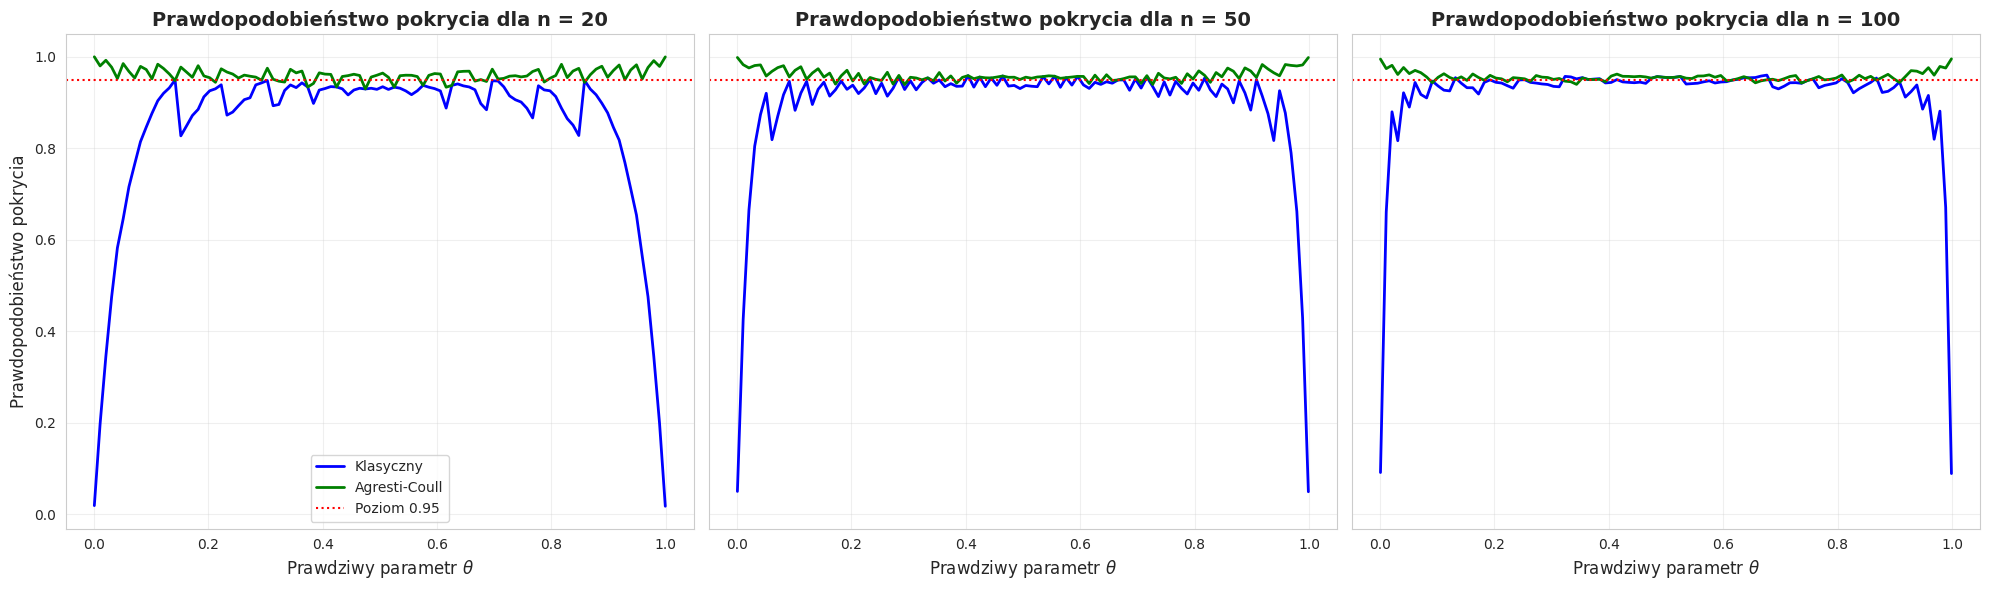

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, n in enumerate(N_LIST):
    ax = axes[i]

    res_classic = results[n]['classic']
    res_ac = results[n]['ac']

    ax.plot(THETA_RANGE, res_classic, label='Klasyczny', color='blue', linewidth=2)
    ax.plot(THETA_RANGE, res_ac, label='Agresti-Coull', color='green', linewidth=2)

    ax.axhline(0.95, color='red', linestyle=':', linewidth=1.5, label='Poziom 0.95')

    ax.set_title(f'Prawdopodobieństwo pokrycia dla n = {n}', fontsize=14, fontweight='bold')
    ax.set_xlabel(r'Prawdziwy parametr $\theta$', fontsize=12)
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.set_ylabel('Prawdopodobieństwo pokrycia', fontsize=12)
        ax.legend(loc='lower center')
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

Metoda Klasyczna (Czerwona linia):

Dla θ bliskich 0 lub 1 (np. <0.05 lub >0.95) prawdopodobieństwo pokrycia gwałtownie spada, często znacznie poniżej zakładanego 0.95.

Jest to spowodowane tym, że gdy wylosujemy same sukcesy lub same porażki (co przy małym n i skrajnym θ jest prawdopodobne), wariancja estymowana jest jako 0, a przedział ufności staje się punktem.

Wykres przypomina odwróconą literę "U".

Metoda Agrestiego-Coulla (Zielona linia):

Jest znacznie bardziej stabilna.

Nawet przy brzegach przedziału (θ≈0 lub 1) utrzymuje pokrycie bliskie lub nawet wyższe niż 0.95.

Widać, że dla małych n (np. n=20) jest nieco konserwatywna (pokrycie często > 0.95), co jest bezpieczniejsze niż niedoszacowanie metody klasycznej.

Wpływ n:

Dla n=100 metoda klasyczna radzi sobie lepiej w szerszym zakresie θ, ale nadal zawodzi na samych krańcach.

Agresti-Coull działa dobrze niezależnie od wielkości próby n.

## Zadanie 4

In [ ]:
REPEATS = 10000
ALPHA = 0.05

In [29]:
def ttest(data, mu_h0):
    """
    Test t-Studenta dla macierzy danych (REPEATS x n).
    Zwraca p-wartości dla każdej próby.
    """
    n = data.shape[1]
    means = np.mean(data, axis=1)
    stds = np.std(data, axis=1, ddof=1)

    t_stats = (means - mu_h0) / (stds / np.sqrt(n))

    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-1))

    return p_values

def calc_proportion_ci(count, nobs, alpha=0.05):
    """Oblicza przedział ufności dla proporcji (np. mocy testu) metodą Wilsona lub normalną"""
    p_hat = count / nobs
    z = stats.norm.ppf(1 - alpha/2)
    margin = z * np.sqrt((p_hat * (1 - p_hat)) / nobs)
    return p_hat, p_hat - margin, p_hat + margin

In [33]:
n = 50
mu_true = 0
sigma = 2
mu_h0 = 0

sample_a = np.random.normal(mu_true, sigma, n)
t_stat_a, p_val_a = stats.ttest_1samp(sample_a, mu_h0)

print(f"--- Podpunkt (a) ---")
print(f"P-wartość: {p_val_a:.4f}")
print(f"Decyzja: {'Odrzucić H0' if p_val_a < ALPHA else 'Brak podstaw do odrzucenia H0'}")

--- Podpunkt (a) ---
P-wartość: 0.3221
Decyzja: Brak podstaw do odrzucenia H0



--- Podpunkt (b) ---
Liczba odrzuceń H0 (Błąd I rodzaju): 529/10000
Oszacowane P(Type I Error): 0.0529
95% Przedział ufności: [0.0485, 0.0573]


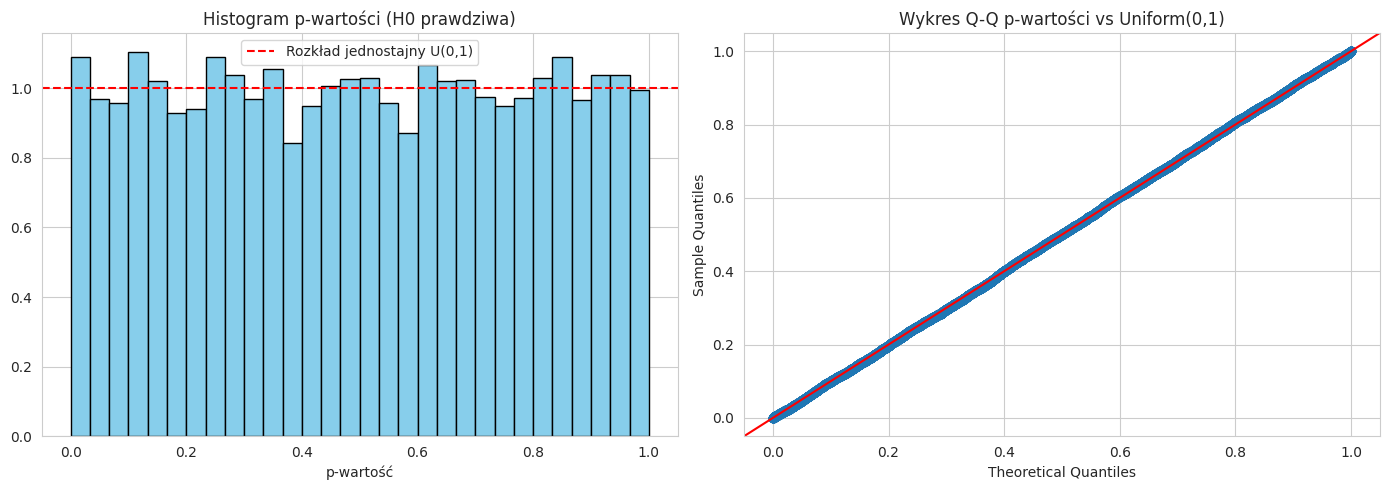

In [34]:
print(f"\n--- Podpunkt (b) ---")
data_b = np.random.normal(mu_true, sigma, (REPEATS, n))

p_values_b = ttest(data_b, mu_h0)

rejections_b = np.sum(p_values_b < ALPHA)
prop_b, ci_low_b, ci_high_b = calc_proportion_ci(rejections_b, REPEATS)

print(f"Liczba odrzuceń H0 (Błąd I rodzaju): {rejections_b}/{REPEATS}")
print(f"Oszacowane P(Type I Error): {prop_b:.4f}")
print(f"95% Przedział ufności: [{ci_low_b:.4f}, {ci_high_b:.4f}]")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(p_values_b, bins=30, color='skyblue', edgecolor='black', density=True)
ax[0].axhline(1, color='red', linestyle='--', label='Rozkład jednostajny U(0,1)')
ax[0].set_title('Histogram p-wartości (H0 prawdziwa)')
ax[0].set_xlabel('p-wartość')
ax[0].legend()

sm.qqplot(p_values_b, dist=stats.uniform, line='45', ax=ax[1])
ax[1].set_title('Wykres Q-Q p-wartości vs Uniform(0,1)')

plt.tight_layout()
plt.show()

In [35]:
n = 50
mu_true = 0.3
sigma = 2
mu_h0 = 0

sample_c = np.random.normal(mu_true, sigma, n)
t_stat_c, p_val_c = stats.ttest_1samp(sample_c, mu_h0)

print(f"--- Podpunkt (c) ---")
print(f"P-wartość: {p_val_c:.4f}")
print(f"Decyzja: {'Odrzucić H0 (Poprawna)' if p_val_c < ALPHA else 'Brak podstaw do odrzucenia H0 (Błąd II rodzaju)'}")

--- Podpunkt (c) ---
P-wartość: 0.0101
Decyzja: Odrzucić H0 (Poprawna)



--- Podpunkt (d) ---
Liczba odrzuceń H0 (Moc testu): 1723/10000
Oszacowana Moc Testu: 0.1723
95% Przedział ufności dla mocy: [0.1649, 0.1797]


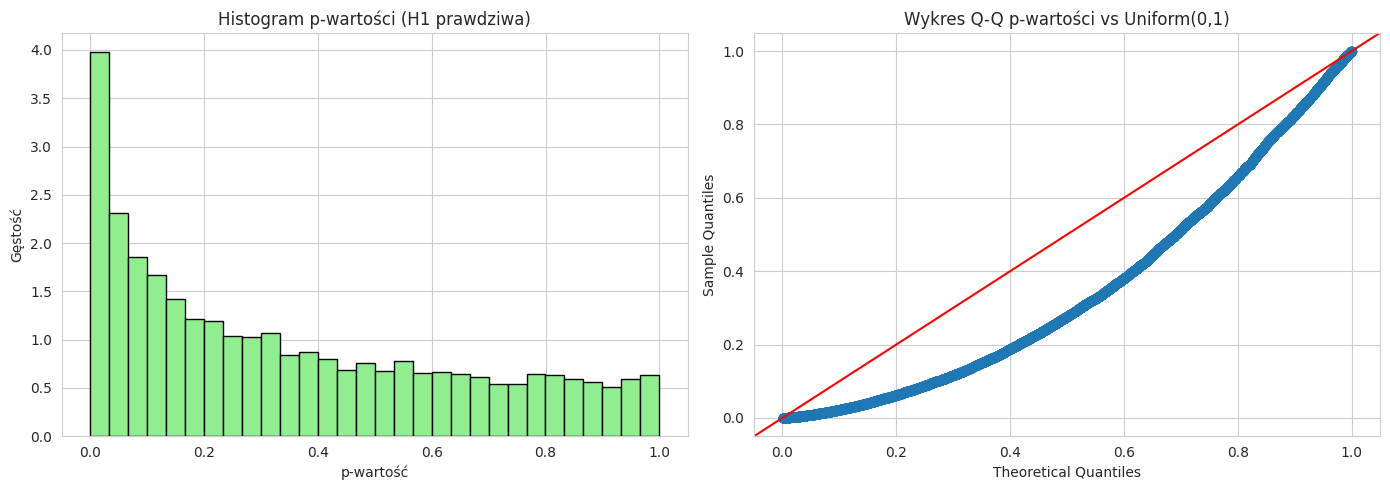

In [36]:
print(f"\n--- Podpunkt (d) ---")
data_d = np.random.normal(mu_true, sigma, (REPEATS, n))
p_values_d = ttest(data_d, mu_h0)

rejections_d = np.sum(p_values_d < ALPHA)
prop_d, ci_low_d, ci_high_d = calc_proportion_ci(rejections_d, REPEATS)

print(f"Liczba odrzuceń H0 (Moc testu): {rejections_d}/{REPEATS}")
print(f"Oszacowana Moc Testu: {prop_d:.4f}")
print(f"95% Przedział ufności dla mocy: [{ci_low_d:.4f}, {ci_high_d:.4f}]")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(p_values_d, bins=30, color='lightgreen', edgecolor='black', density=True)
ax[0].set_title('Histogram p-wartości (H1 prawdziwa)')
ax[0].set_xlabel('p-wartość')
ax[0].set_ylabel('Gęstość')

sm.qqplot(p_values_d, dist=stats.uniform, line='45', ax=ax[1])
ax[1].set_title('Wykres Q-Q p-wartości vs Uniform(0,1)')

plt.tight_layout()
plt.show()

In [37]:
def calculate_power(n, mu_true, sigma, repeats=2000):
    """Pomocnicza funkcja do liczenia mocy dla zadanych parametrów"""
    data = np.random.normal(mu_true, sigma, (repeats, n))
    p_vals = ttest(data, mu_h0=0)
    return np.mean(p_vals < 0.05)

In [39]:
mu1_range = np.linspace(0, 1.5, 30)
n_range = np.arange(10, 200, 5)
sigma2_range = np.linspace(0.5, 10, 30)

powers_mu = []
powers_n = []
powers_sigma = []

for m in mu1_range:
    powers_mu.append(calculate_power(n=50, mu_true=m, sigma=2))

for n_val in n_range:
    powers_n.append(calculate_power(n=n_val, mu_true=0.3, sigma=2))

for s2 in sigma2_range:
    powers_sigma.append(calculate_power(n=50, mu_true=0.3, sigma=np.sqrt(s2)))

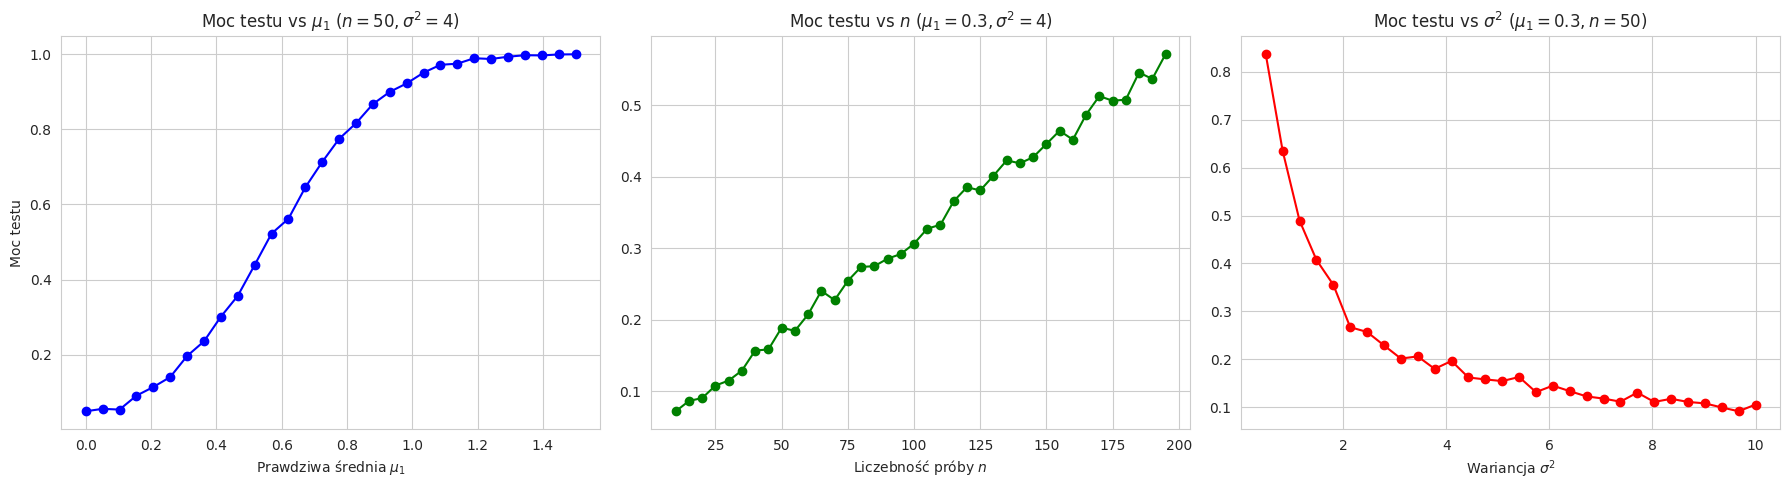

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(mu1_range, powers_mu, 'o-', color='blue')
axes[0].set_title(r'Moc testu vs $\mu_1$ ($n=50, \sigma^2=4$)')
axes[0].set_xlabel(r'Prawdziwa średnia $\mu_1$')
axes[0].set_ylabel('Moc testu')
axes[0].grid(True)

axes[1].plot(n_range, powers_n, 'o-', color='green')
axes[1].set_title(r'Moc testu vs $n$ ($\mu_1=0.3, \sigma^2=4$)')
axes[1].set_xlabel(r'Liczebność próby $n$')
axes[1].grid(True)

axes[2].plot(sigma2_range, powers_sigma, 'o-', color='red')
axes[2].set_title(r'Moc testu vs $\sigma^2$ ($\mu_1=0.3, n=50$)')
axes[2].set_xlabel(r'Wariancja $\sigma^2$')
axes[2].grid(True)

plt.tight_layout()
plt.show()

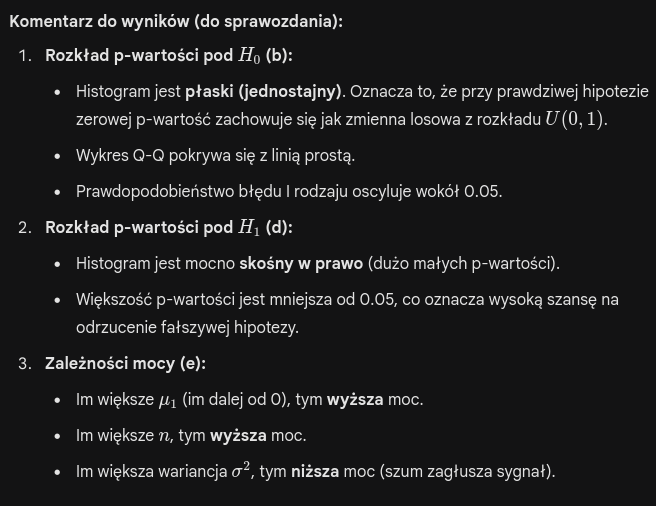